1. Імпорт бібліотек та налаштування

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Налаштування стилю графіків для гарного вигляду
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

2. Зчитування та Data Cleaning

In [2]:
# Завантаження датасету
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
column_names = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 
                'acceleration', 'model_year', 'origin', 'car_name']

# Файл розділений пробілами різної довжини
df = pd.read_csv(url, sep=r'\s+', names=column_names)

print("Розмір до очищення:", df.shape)

# DATA CLEANING: 
# 1. Замінюємо '?' у horsepower на NaN
df['horsepower'] = df['horsepower'].replace('?', np.nan)

# 2. Видаляємо рядки з відсутніми даними (Missing Values)
df = df.dropna()

# 3. Перетворюємо horsepower у числовий формат (float)
df['horsepower'] = df['horsepower'].astype(float)

# 4. Перетворюємо origin (1, 2, 3) у зрозумілі категорії для красивих графіків
origin_map = {1: 'USA', 2: 'Europe', 3: 'Japan'}
df['origin'] = df['origin'].map(origin_map)

print("Розмір після очищення:", df.shape)
display(df.sample(5))

Розмір до очищення: (398, 9)
Розмір після очищення: (392, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
299,27.2,4,141.0,71.0,3190.0,24.8,79,Europe,peugeot 504
291,19.2,8,267.0,125.0,3605.0,15.0,79,USA,chevrolet malibu classic (sw)
101,23.0,6,198.0,95.0,2904.0,16.0,73,USA,plymouth duster
370,31.0,4,112.0,85.0,2575.0,16.2,82,USA,pontiac j2000 se hatchback
210,19.0,6,156.0,108.0,2930.0,15.5,76,Japan,toyota mark ii


3. Графік 1 — Залежність (Scatter plot)

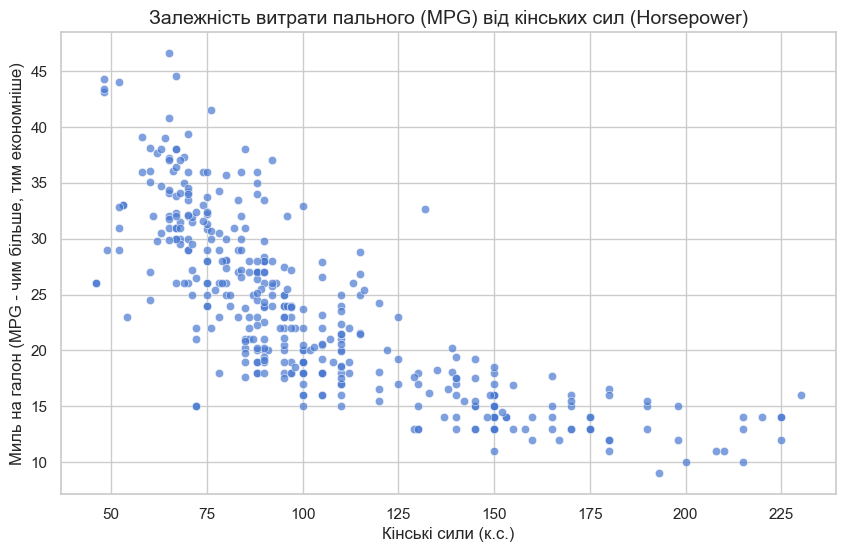

In [3]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='horsepower', y='mpg', alpha=0.7, color='b')
plt.title('Залежність витрати пального (MPG) від кінських сил (Horsepower)', fontsize=14)
plt.xlabel('Кінські сили (к.с.)')
plt.ylabel('Миль на галон (MPG - чим більше, тим економніше)')
plt.show()

4. Графік 2 — Гістограма з 5 діапазонами

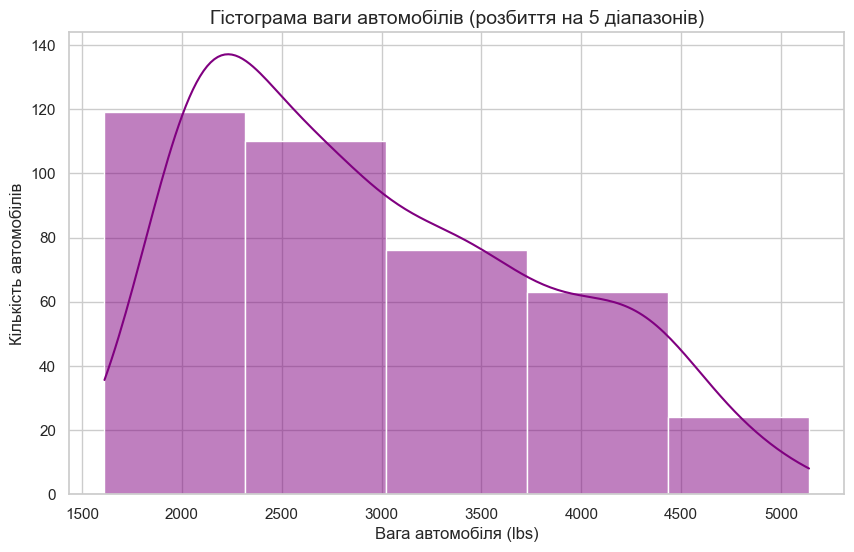

In [4]:
plt.figure(figsize=(10, 6))
# Параметр bins=5 чітко розбиває дані на 5 кошиків
sns.histplot(data=df, x='weight', bins=5, kde=True, color='purple')
plt.title('Гістограма ваги автомобілів (розбиття на 5 діапазонів)', fontsize=14)
plt.xlabel('Вага автомобіля (lbs)')
plt.ylabel('Кількість автомобілів')
plt.show()

5. Графік 3 — Багатовимірна візуалізація (3D на площині)

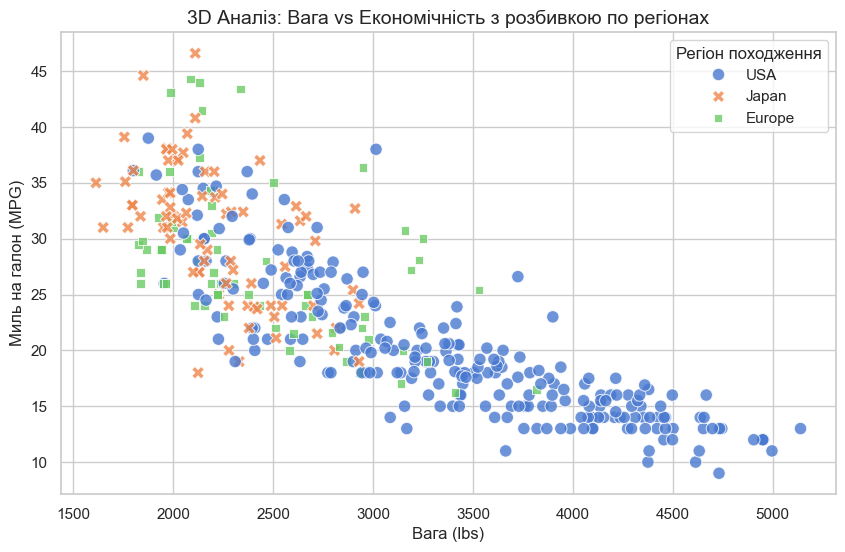

In [5]:
plt.figure(figsize=(10, 6))
# 3 виміри: x=weight, y=mpg, колір(hue)=origin
sns.scatterplot(data=df, x='weight', y='mpg', hue='origin', style='origin', s=80, alpha=0.8)
plt.title('3D Аналіз: Вага vs Економічність з розбивкою по регіонах', fontsize=14)
plt.xlabel('Вага (lbs)')
plt.ylabel('Миль на галон (MPG)')
plt.legend(title='Регіон походження')
plt.show()

6. Графік 4 — Багатовимірна візуалізація (4D Bubble Chart)

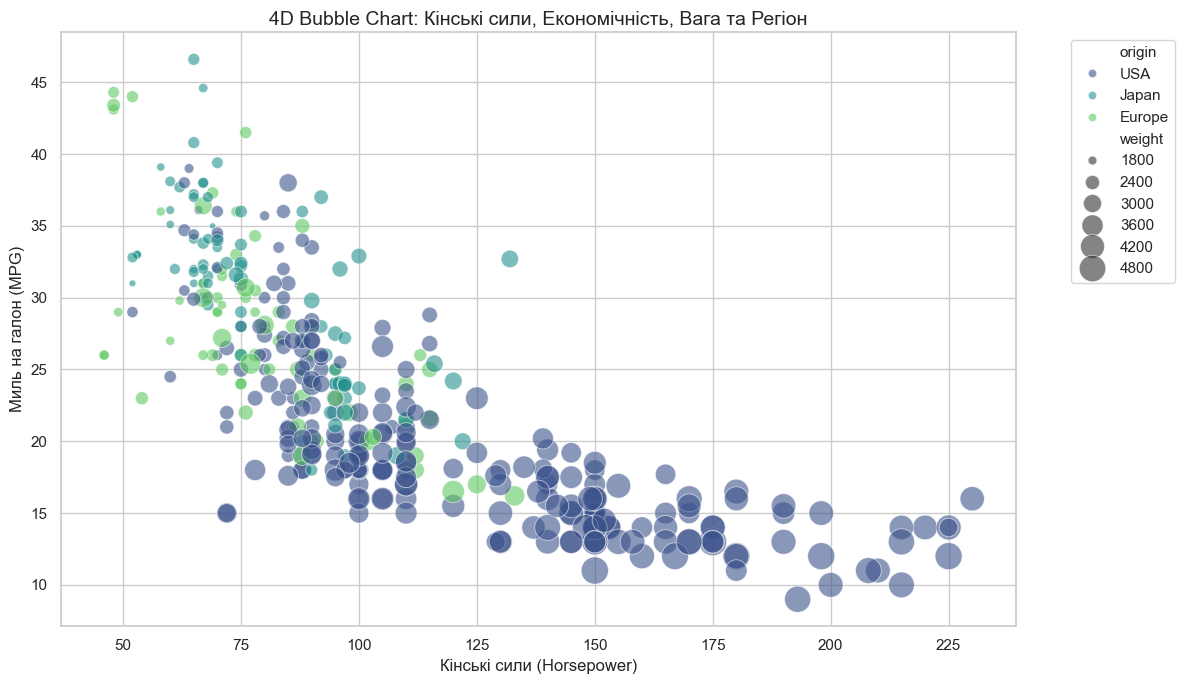

In [6]:
plt.figure(figsize=(12, 7))
# 4 виміри: x=horsepower, y=mpg, колір(hue)=origin, розмір(size)=weight
sns.scatterplot(data=df, x='horsepower', y='mpg', hue='origin', size='weight', 
                sizes=(20, 400), alpha=0.6, palette='viridis')
plt.title('4D Bubble Chart: Кінські сили, Економічність, Вага та Регіон', fontsize=14)
plt.xlabel('Кінські сили (Horsepower)')
plt.ylabel('Миль на галон (MPG)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

7. Графік 5 — Категоріальна багатовимірність (Violin Plot)

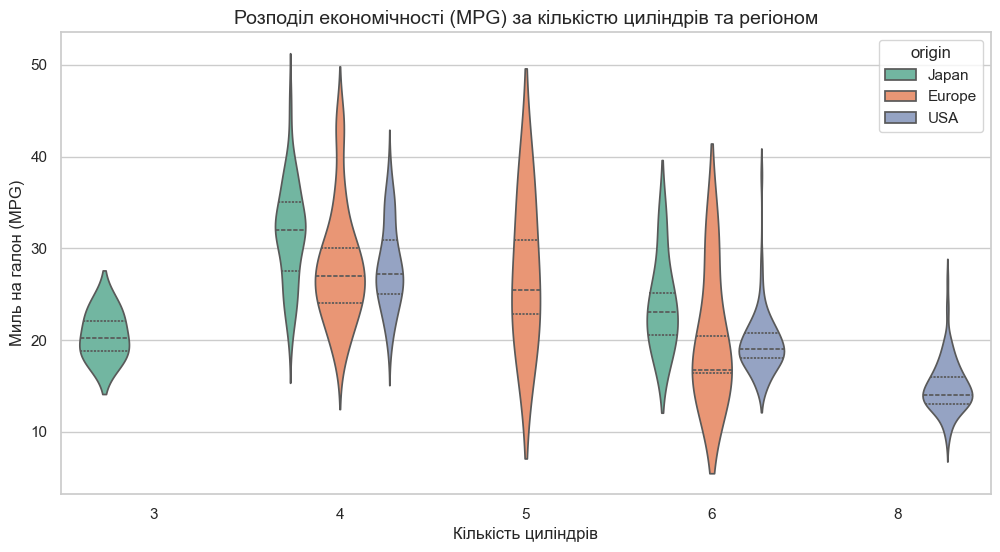

In [7]:
plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x='cylinders', y='mpg', hue='origin', palette='Set2', inner='quartile')
plt.title('Розподіл економічності (MPG) за кількістю циліндрів та регіоном', fontsize=14)
plt.xlabel('Кількість циліндрів')
plt.ylabel('Миль на галон (MPG)')
plt.show()

8: Графік 6 — Теплова карта кореляції (Heatmap)

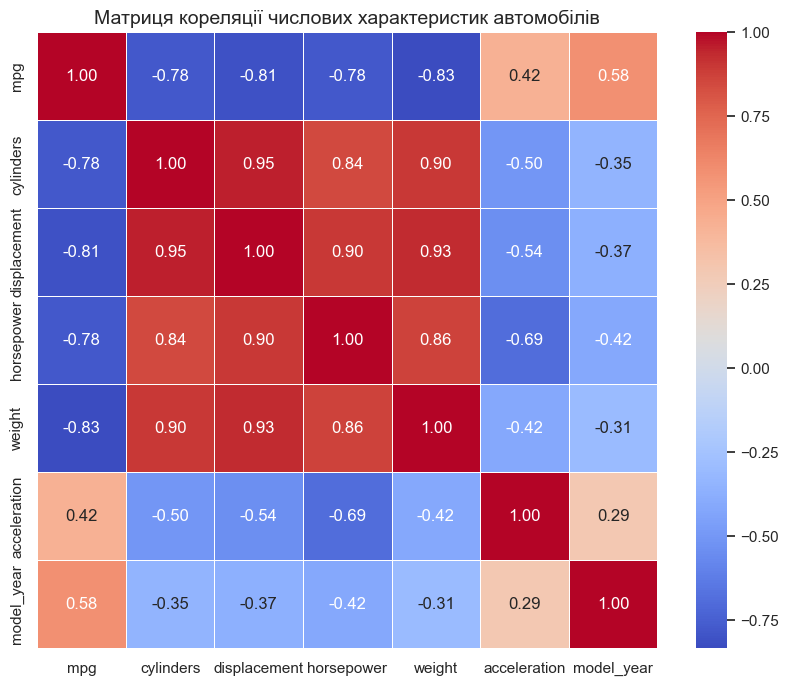

In [8]:
plt.figure(figsize=(10, 8))
# Вибираємо тільки числові колонки для матриці кореляції
numeric_cols = df.select_dtypes(include=[np.number])
corr_matrix = numeric_cols.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Матриця кореляції числових характеристик автомобілів', fontsize=14)
plt.show()